In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Improving Olist's Estimated Delivery Time (ETA)

👉 `Estimated Time of Arrival (ETA)` is a key component of modern e-commerce services. It allows companies to manage customer expectations by showing a predicted date for customer delivery.

🎯 In this challenge, we will build a predictive model that `estimates the wait time` of an order.

☑️ Olist already has its own predictions under the variable `expected_wait_time`

🚀 Let's challenge ourselves to do better predictions and at the end of this recap, 
we will compare:
* our `estimated_wait_time`
* Olist's `expected_wait_time`
* the real `wait_time` for each order delivered

## Load and check `orders` dataset

👉 `Order().get_training_data()` (include `distance_seller_customer`)

In [2]:
from olist.order import Order
orders = Order().get_training_data(with_distance_seller_customer=True)

In [3]:
orders.head(3)

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status,dim_is_five_star,dim_is_one_star,review_score,number_of_items,number_of_sellers,price,freight_value,distance_seller_customer
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0.0,delivered,0,0,4,1,1,29.99,8.72,18.063837
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0.0,delivered,0,0,4,1,1,118.70,22.76,856.292580
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0.0,delivered,1,0,5,1,1,159.90,19.22,514.130333


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95872 entries, 0 to 95879
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  95872 non-null  object 
 1   wait_time                 95872 non-null  float64
 2   expected_wait_time        95872 non-null  float64
 3   delay_vs_expected         95872 non-null  float64
 4   order_status              95872 non-null  object 
 5   dim_is_five_star          95872 non-null  int64  
 6   dim_is_one_star           95872 non-null  int64  
 7   review_score              95872 non-null  int64  
 8   number_of_items           95872 non-null  int64  
 9   number_of_sellers         95872 non-null  int64  
 10  price                     95872 non-null  float64
 11  freight_value             95872 non-null  float64
 12  distance_seller_customer  95872 non-null  float64
dtypes: float64(6), int64(5), object(2)
memory usage: 10.2+ MB


## Baseline Model - Olist’s current ETA model

🐣  What's the baseline we want to optimize ❓

👉 The delta between Olist' `expected_wait_time` and the real `wait_time`

📈 Plot their respective histograms

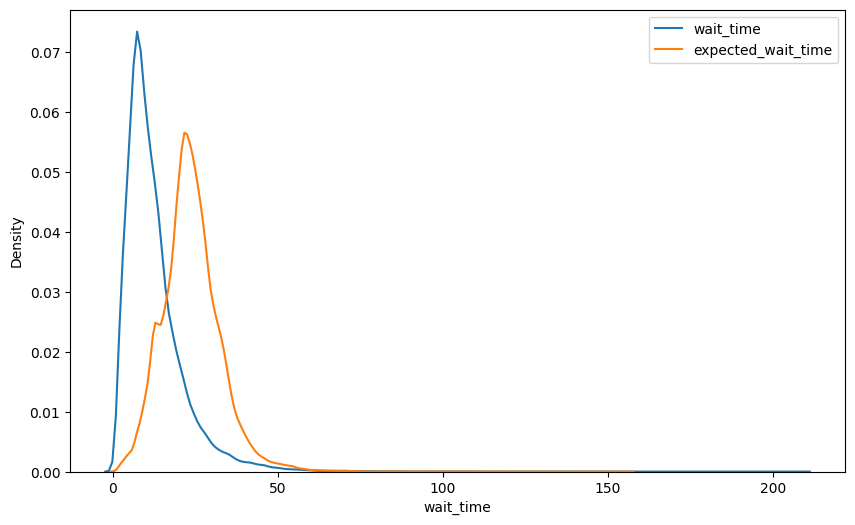

In [5]:
# Plot distributions of expected_wait_time and real wait_time
plt.figure(figsize = (10,6))
sns.kdeplot(orders['wait_time'], label='wait_time')
sns.kdeplot(orders['expected_wait_time'], label='expected_wait_time')
plt.legend()

👉 What is the median wait time ? the median expected wait time ? 

In [6]:
# Compute medians
orders[['wait_time', 'expected_wait_time']].median()

wait_time             10.203727
expected_wait_time    23.230556
dtype: float64

👉 Compute the baseline RMSE 

ℹ️ The errors considered here are the misapproximations from Olist in terms of waiting time.

In [7]:
errors_from_olist = orders['expected_wait_time'] - orders['wait_time']

baseline_RMSE = ((errors_from_olist**2).mean())**0.5
baseline_RMSE

15.110701386210625

## OLS multivariate model

👉 We will create an OLS model using the `statsmodel.api.OLS` method this time.

(instead of `statsmodel.formula.api.ols`) 

### Prepare the dataset with the  features X and the target Y

In [8]:
orders.columns

Index(['order_id', 'wait_time', 'expected_wait_time', 'delay_vs_expected',
       'order_status', 'dim_is_five_star', 'dim_is_one_star', 'review_score',
       'number_of_items', 'number_of_sellers', 'price', 'freight_value',
       'distance_seller_customer'],
      dtype='object')

In [9]:
# Create target variable y (Series)  and feature X (DataFrame) without data leaks!

y = orders["wait_time"].copy()

X = orders[[
    "number_of_items",
    "number_of_sellers",
    "price",
    "freight_value",
    "distance_seller_customer"
    ]].copy()

X

,number_of_items,number_of_sellers,price,freight_value,distance_seller_customer
0,1,1,29.99,8.72,18.063837
1,1,1,118.70,22.76,856.292580
2,1,1,159.90,19.22,514.130333
3,1,1,45.00,27.20,1822.800366
4,1,1,19.90,8.72,30.174037
...,...,...,...,...,...
95875,1,1,72.00,13.08,69.481037
95876,1,1,174.90,20.10,474.098245
95877,1,1,205.99,65.02,968.051192
95878,2,1,359.98,81.18,370.146853


⚖️ Standardize (`z-score`) each feature of X to compare regression coefficients that will result from the OLS:

In [10]:
X_std = X.copy()

for f in X.columns:
    mu = X[f].mean()
    sigma = X[f].std()
    X_std[f] = X[f].map(lambda x: (x - mu) / sigma)

X_std

,number_of_items,number_of_sellers,price,freight_value,distance_seller_customer
0,-0.264595,-0.112544,-0.513802,-0.652038,-0.979475
1,-0.264595,-0.112544,-0.086640,0.000467,0.429743
2,-0.264595,-0.112544,0.111748,-0.164053,-0.145495
3,-0.264595,-0.112544,-0.441525,0.206815,2.054621
4,-0.264595,-0.112544,-0.562388,-0.652038,-0.959115
...,...,...,...,...,...
95875,-0.264595,-0.112544,-0.311513,-0.449408,-0.893033
95876,-0.264595,-0.112544,0.183977,-0.123156,-0.212797
95877,-0.264595,-0.112544,0.333684,1.964490,0.617630
95878,1.601605,-0.112544,1.075186,2.715522,-0.387558


In [11]:
# Check how different is it from the "formula" in statsmodel
import patsy
patsy.dmatrix('price + distance_seller_customer', orders)

DesignMatrix with shape (95872, 3)
  Intercept   price  distance_seller_customer
          1   29.99                  18.06384
          1  118.70                 856.29258
          1  159.90                 514.13033
          1   45.00                1822.80037
          1   19.90                  30.17404
          1  147.90                 411.95300
          1   59.99                 321.73040
          1   19.90                 872.66930
          1  149.99                 111.51773
          1  198.00                 413.25219
          1   98.00                 844.97722
          1   31.90                 452.20571
          1   19.90                 308.45551
          1   38.25                 430.59899
          1  132.40                 161.60460
          1   27.99                 547.73905
          1   17.90                 209.39770
          1   76.00                1434.17366
          1  109.90                  11.84639
          1   79.99                  19.27366

⚠️ With this `statsmodel.api.OLS`, we always need to add a constant "intercept" to the features dataset:

In [12]:
X_std['constant'] = 1
X_std

,number_of_items,number_of_sellers,price,freight_value,distance_seller_customer,constant
0,-0.264595,-0.112544,-0.513802,-0.652038,-0.979475,1
1,-0.264595,-0.112544,-0.086640,0.000467,0.429743,1
2,-0.264595,-0.112544,0.111748,-0.164053,-0.145495,1
3,-0.264595,-0.112544,-0.441525,0.206815,2.054621,1
4,-0.264595,-0.112544,-0.562388,-0.652038,-0.959115,1
...,...,...,...,...,...,...
95875,-0.264595,-0.112544,-0.311513,-0.449408,-0.893033,1
95876,-0.264595,-0.112544,0.183977,-0.123156,-0.212797,1
95877,-0.264595,-0.112544,0.333684,1.964490,0.617630,1
95878,1.601605,-0.112544,1.075186,2.715522,-0.387558,1


### Run OLS with `statsmodels` and print `summary`

In [13]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = sm.OLS(y,X_std).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              wait_time   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.161
Method:                 Least Squares   F-statistic:                     3676.
Date:                Thu, 01 May 2025   Prob (F-statistic):               0.00
Time:                        13:05:10   Log-Likelihood:            -3.4301e+05
No. Observations:               95872   AIC:                         6.860e+05
Df Residuals:                   95866   BIC:                         6.861e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
number_of_items             -0.3104      0.033     -9.481      0.000      -0.375      -0.246
number_of_sellers           -0.3557      0.029    -12.174      0.000      -0.413      -0.298
price                        0.0474      0.031      1.542      0.123      -0.013       0.108
freight_value                0.6392      0.036     17.717      0.000       0.568       0.710
distance_seller_customer     3.5219      0.030    117.298      0.000       3.463       3.581
constant                    12.5134      0.028    447.350      0.000      12.459      12.568
==============================================================================
Omnibus:                    91515.661   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         10123039.937
Skew:                           4.333   Prob(JB):                         0.00
Kurtosis:                      52.589   Cond. No.                         2.18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Check the performance of your OLS model

### Goodness of fit

👉 Who has the best predictions, you or Olist ? 

- Compute your predictions and store them in `y_pred`

- You can store :
    - Olist's predictions in a `y_expected_olist` variable
    - the real waiting times in a `y_true` variable



In [14]:
# Olist predictions
y_expected_olist = orders['expected_wait_time']

# Your predictions
y_pred = model.predict(X_std)

# The real waiting times
y_true = orders['wait_time']


📈 Plot `y_pred`, `y_expected_olist` and `y_true` on the same graph.

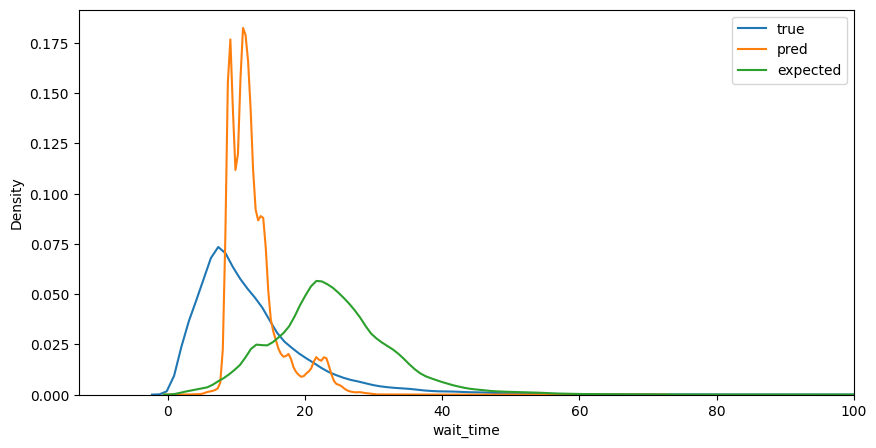

In [15]:
plt.figure(figsize = (10,5))
sns.kdeplot(y_true, label = 'true')
sns.kdeplot(y_pred, label = 'pred')
sns.kdeplot(y_expected_olist, label = 'expected')
plt.xlim(xmax=100)
plt.legend()

👉 Compute the RMSE where the errors are now *your* errors !

In [16]:
# Compute RMSE (i.e 𝛔(residuals))
residuals_lewagon = y_pred - y_true
RMSE_lewagon = (residuals_lewagon**2).mean()**0.5
RMSE_lewagon

8.660865913751271

Just as a reminder, Olist's RMSE was equal to : 👇

In [17]:
baseline_RMSE

15.110701386210625

😏 Did we really beat Olist's Data Scientists ? We cannot really say that!

- In many e-commerce and delivery services, the ETA is often overestimated...
- When customers receive their orders earlier than expected, they are more likely to be satisfied !

### Partial correlations

👉 Visualize partial correlations with `sm.graphics.plot_partregress_grid`

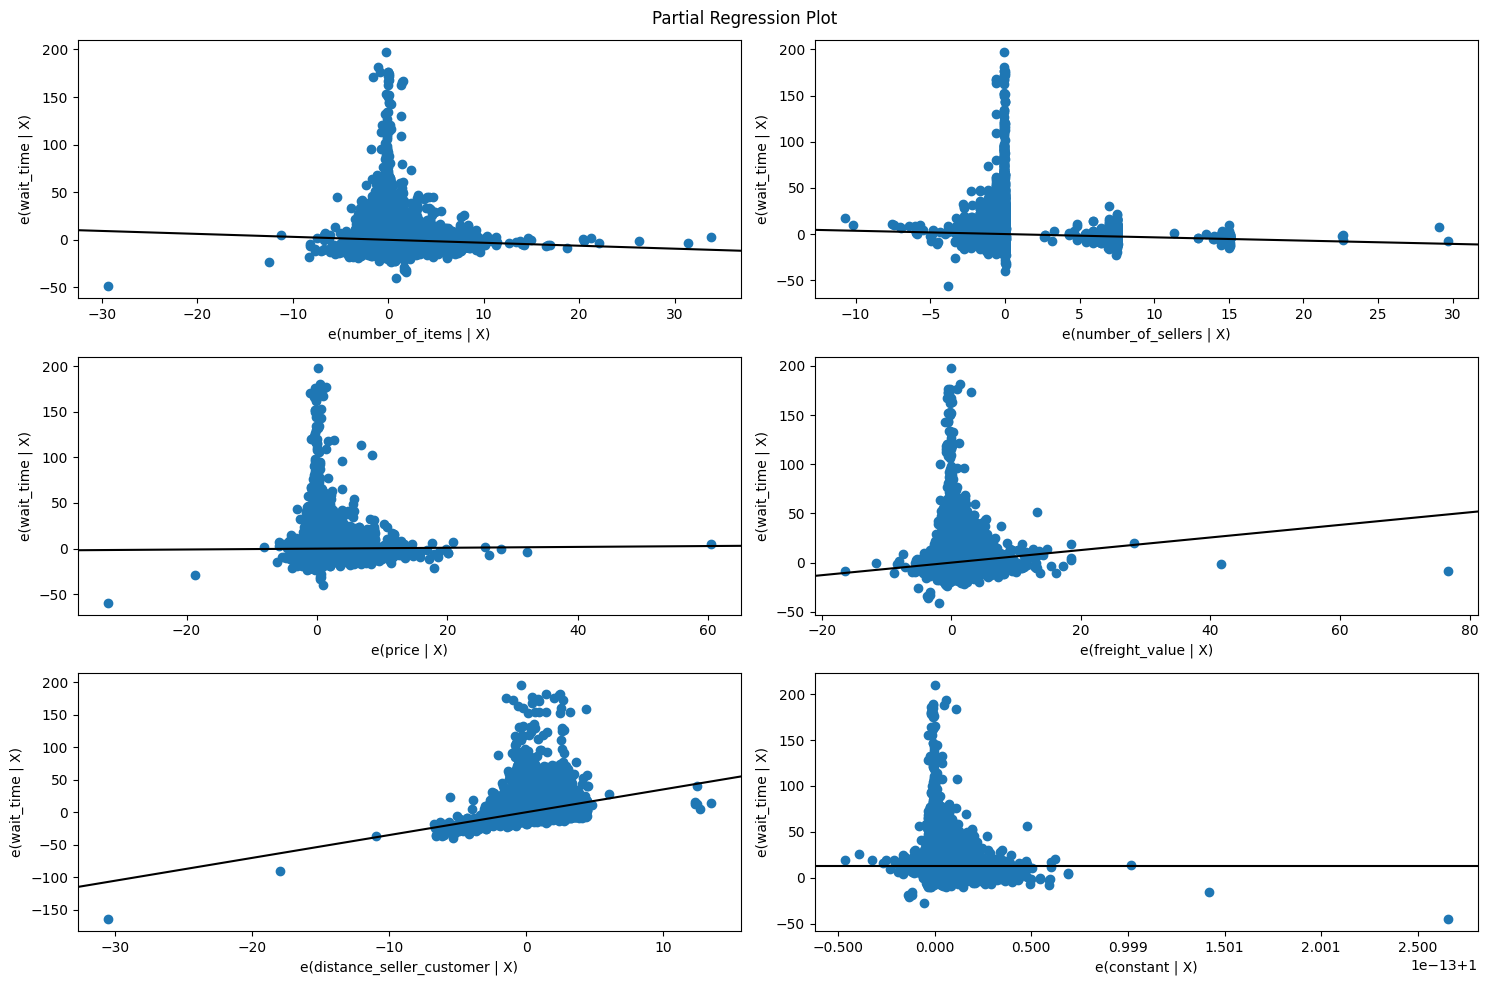

In [18]:
fig = plt.figure(figsize=(15,10))
sm.graphics.plot_partregress_grid(model, fig=fig)
plt.show()

**How do we read these graphs ?**

👉 Let's focus - for instance - on the graph in the bottom left corner:

<u>Partial regression of `wait_time` against `distance`</u>

- Each point is an order in our dataset


- `y-axis`: residuals of the `wait_time`, using all features except `distance`

    - These residuals contain the remaining information about `wait_time` that couldn't be explained without `distance`


- `x-axis`: residuals of predicting `distance` by using all other features (price, freight_value, etc...)
    - These residuals contain the new information that `distance` brings to the table, which is not already explained by the other features in the model.



### Inferential conditions

⚠️ Check you residuals. Are they normally distributed?

<Axes: ylabel='Density'>

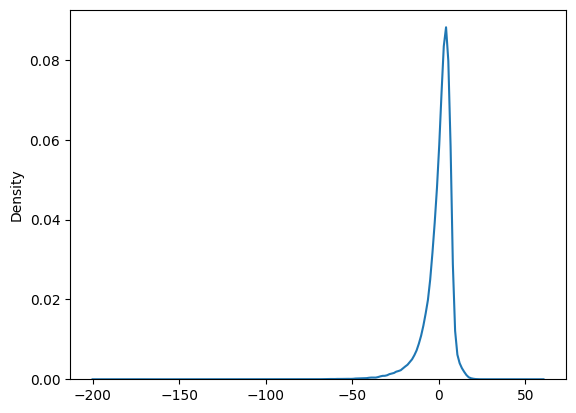

In [19]:
sns.kdeplot(residuals_lewagon)

🎁 A more precise way to visualize whether a distribution is Gaussian or not is the <a href="https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html">**`QQplot`**</a>. 

📈 Plot the QQplot of your residual below

💡 Make sure to understand the relation between the QQ plot and the density previsouly drawn..

📚 <a href="https://stats.stackexchange.com/questions/101274/how-to-interpret-a-qq-plot">Stats.StackExchange.com - Interpreting QQplots</a>

- `x-axis` : theoretical quantiles of a Gaussian distribution
- `y-axis`: quantiles of the sorted variable

💡 If the <span style="color:blue">blue</span> points are aligned on the <span style="color:red">red line</span> which is the identity function, the variable has a Gaussian distribution !

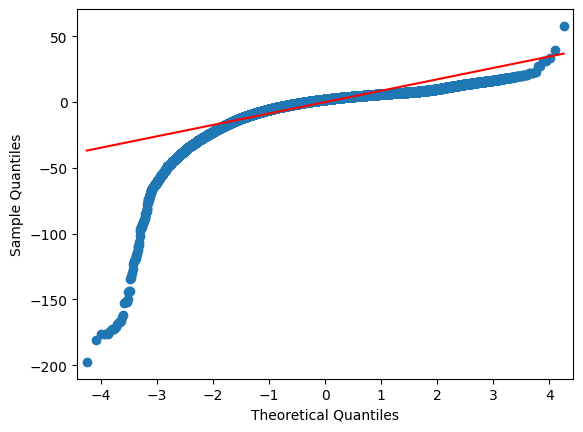

In [20]:
sm.qqplot(residuals_lewagon, line='s');

#### Some QQplot examples:

Run the cells below to understand how QQ plots are graphed:

In [21]:
from scipy import stats
stats.norm.rvs(0,1)

1.731622814628194

(-5.0994079434895845, 10.0)

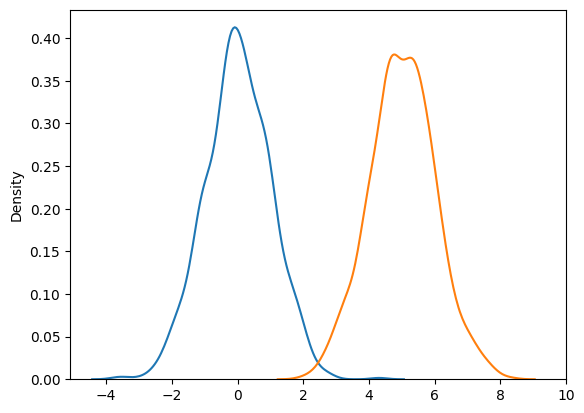

In [22]:
# lets check QQ plots with our own distributions
from scipy import stats

norm_1 = [stats.norm.rvs(0,1) for x in range(1000)]
norm_2 = [stats.norm.rvs(5,1) for x in range(1000)]

sns.kdeplot(norm_1)
sns.kdeplot(norm_2)
plt.xlim(right=10)

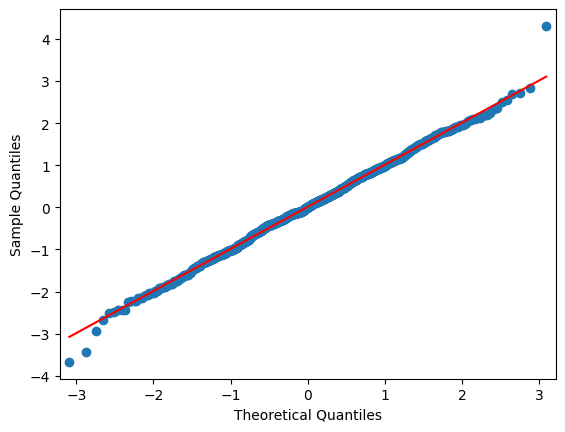

In [23]:
sm.qqplot(np.asarray(norm_1), line='s');

(-6.214388281077526, 10.0)

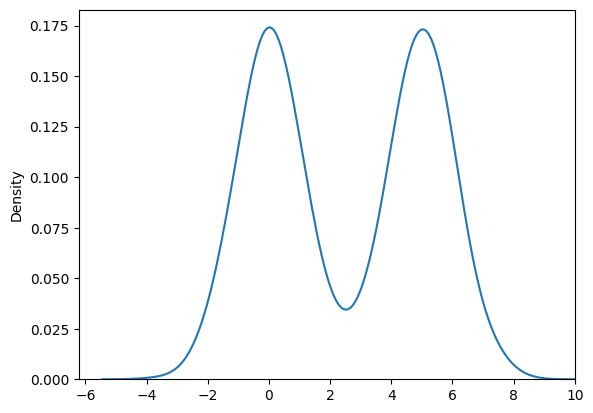

In [24]:
bimodal = norm_1 + norm_2
sns.kdeplot(bimodal)
plt.xlim(right=10)

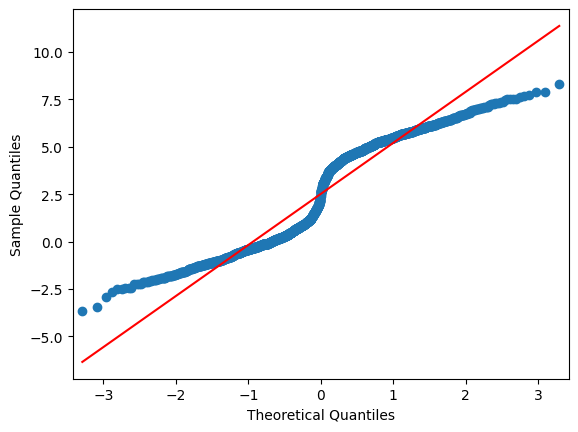

In [25]:
sm.qqplot(np.asarray(bimodal), line='s');

<img src="https://wagon-public-datasets.s3.amazonaws.com/04-Decision-Science/03-Linear-Regression/qq_plot_interpretation.png" width=400>

#### Check residuals vs. fitted to see if we can detect any non-random pattern

(0.0, 50.0)

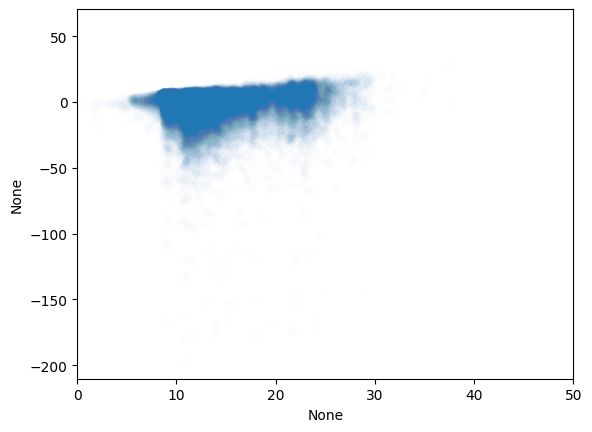

In [26]:
sns.scatterplot(x = y_pred, y = residuals_lewagon, alpha=0.01)
plt.xlim(xmin=0, xmax=50)

## More Features? (Optional)

Here we can add additional features from the product details (size, category etc..)

### Add product details associated with each order (sum of product sizes, sum of weights etc...)

In [27]:
from olist.data import Olist
data = Olist().get_data()
products = data['products']
order_items = data['order_items']

In [28]:
order_items_products = (
    order_items.groupby(["order_id", "product_id"], as_index=False)
    .agg({"order_item_id": "count"})
    .rename(columns={"order_item_id": "order_item_count"})
    .merge(products.drop(["product_category_name"], axis=1), on="product_id")
)
order_items_products

,order_id,product_id,order_item_count,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,1,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,1,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,1,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,1,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,1,59.0,409.0,1.0,3750.0,35.0,40.0,30.0
...,...,...,...,...,...,...,...,...,...,...
102420,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,1,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
102421,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,1,31.0,232.0,1.0,8950.0,45.0,26.0,38.0
102422,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,1,43.0,869.0,1.0,967.0,21.0,24.0,19.0
102423,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,1,56.0,1306.0,1.0,100.0,20.0,20.0,20.0


In [29]:
# Since we want the sum of product weights per order from our new DataFrame, we need to multiply weight by product count
order_items_products['product_weight_g'] = order_items_products['product_weight_g'] *  order_items_products['order_item_count']

order_items_features = order_items_products.groupby("order_id", as_index=False).agg(
    {
        "product_weight_g": "sum",
        "product_length_cm": "max",
        "product_height_cm": "max",
        "product_width_cm": "max",
    }).rename(columns={
        "product_weight_g": "product_weight_g_sum",
        "product_length_cm": "product_length_cm_max",
        "product_height_cm": "product_height_cm_max",
        "product_width_cm": "product_width_cm_max",
    })
order_items_features

,order_id,product_weight_g_sum,product_length_cm_max,product_height_cm_max,product_width_cm_max
0,00010242fe8c5a6d1ba2dd792cb16214,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,3750.0,35.0,40.0,30.0
...,...,...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,10150.0,89.0,15.0,40.0
98662,fffcd46ef2263f404302a634eb57f7eb,8950.0,45.0,26.0,38.0
98663,fffce4705a9662cd70adb13d4a31832d,967.0,21.0,24.0,19.0
98664,fffe18544ffabc95dfada21779c9644f,100.0,20.0,20.0,20.0


In [30]:
orders_with_details = orders.merge(order_items_features, on="order_id", how="left").dropna()

In [31]:
X2 = orders_with_details[[
        "number_of_items",
        "number_of_sellers",
        "price",
        "freight_value",
        "distance_seller_customer",
        "product_weight_g_sum",
        "product_length_cm_max",
        "product_height_cm_max",
        "product_width_cm_max"]].copy()
y2 = orders_with_details["wait_time"].copy()

In [32]:
# standardize (z-normalize) each features of X to compare coefficients
for f in X2.columns:
    mu = X2[f].mean()
    sigma = X2[f].std()
    X2[f] = X2[f].map(lambda x: (x - mu) / sigma)

In [33]:
X2['constant'] = 1

In [34]:
model2 = sm.OLS(y2, X2).fit()

In [35]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              wait_time   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     2112.
Date:                Thu, 01 May 2025   Prob (F-statistic):               0.00
Time:                        13:05:58   Log-Likelihood:            -3.4269e+05
No. Observations:               95856   AIC:                         6.854e+05
Df Residuals:                   95846   BIC:                         6.855e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
number_of_items             -0.1747      0.033     -5.232      0.000      -0.240      -0.109
number_of_sellers           -0.3686      0.029    -12.600      0.000      -0.426      -0.311
price                       -0.0249      0.031     -0.805      0.421      -0.085       0.036
freight_value                0.0912      0.046      1.994      0.046       0.002       0.181
distance_seller_customer     3.7073      0.031    117.856      0.000       3.646       3.769
product_weight_g_sum         0.4430      0.045      9.860      0.000       0.355       0.531
product_length_cm_max        0.4018      0.034     11.661      0.000       0.334       0.469
product_height_cm_max        0.2364      0.033      7.061      0.000       0.171       0.302
product_width_cm_max        -0.0428      0.035     -1.213      0.225      -0.112       0.026
constant                    12.5135      0.028    448.526      0.000      12.459      12.568
==============================================================================
Omnibus:                    91611.645   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         10185560.909
Skew:                           4.340   Prob(JB):                         0.00
Kurtosis:                      52.748   Cond. No.                         3.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""